# 42 - An?lise das descri??es preprocessadas para TF-IDF

**Objetivo:** entender quais textos ser?o fornecidos ao TF-IDF, como variam as descri??es preprocessadas e quais palavras dominam o conjunto.

A an?lise compara `descricao_normalizada` (representa??o principal) com as tr?s variantes experimentais produzidas no notebook 41. Ela mostra estat?sticas de tamanho, distribui??o de tokens, termos mais comuns e exemplos. A frequ?ncia de cada descri??o ? apresentada como contexto de ocorr?ncias reais; o TF-IDF do notebook 45 usa uma linha por descri??o ?nica e n?o pondera por `frequencia`.

A tokeniza??o deste notebook segue o padr?o usual do `TfidfVectorizer` do scikit-learn (`(?u)\b\w\w+\b`): tokens de um caractere s?o ignorados. N?o h? grava??o de arquivos.

In [24]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Execute a partir da raiz do reposit?rio ou da pasta notebooks.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_PATH = Path(
    "data/processed/items-notas-fiscais-filtros-combinados-experimentos-texto/"
    "items-notas-fiscais-filtros-combinados-experimentos-texto-202501-202504.parquet"
)
FREQUENCY_COLUMN = "frequencia"
DESCRIPTION_COLUMNS = {
    "Normalizada (entrada principal)": "descricao_normalizada",
    "Abrevia??es e unidades": "descricao_abreviacoes_unidades",
    "Espa?amento n?mero-unidade": "descricao_numero_unidade_padronizada",
    "N?meros mascarados": "descricao_numeros_mascarados",
}
TOP_N = 30
SAMPLE_SIZE = 30
RANDOM_SEED = 42

INPUT_PATH = PROJECT_ROOT / DATASET_PATH
INPUT_PATH

WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/processed/items-notas-fiscais-filtros-combinados-experimentos-texto/items-notas-fiscais-filtros-combinados-experimentos-texto-202501-202504.parquet')

## Fun??es da an?lise

As tabelas de palavras incluem duas perspectivas: contagem de tokens entre descri??es ?nicas e contagem ponderada por `frequencia`. A primeira descreve os documentos que entram no TF-IDF; a segunda aproxima quantas ocorr?ncias dos itens fiscais cada termo representa.

In [25]:
def tokenize_description(value: object) -> list[str]:
    """Tokenize a description using scikit-learn's default word token pattern."""
    if pd.isna(value):
        return []
    return re.findall(r"(?u)\b\w\w+\b", str(value).lower())


def summarize_description_column(frame: pd.DataFrame, column: str) -> dict[str, float]:
    """Calculate document-level text length and token statistics for a column."""
    tokens_by_row = frame[column].fillna("").map(tokenize_description)
    token_counts = tokens_by_row.map(len)
    character_counts = frame[column].fillna("").astype(str).str.len()
    return {
        "descri??es ?nicas": len(frame),
        "descri??es sem token": int(token_counts.eq(0).sum()),
        "tokens totais (documentos)": int(token_counts.sum()),
        "tokens por descri??o ? mediana": float(token_counts.median()),
        "tokens por descri??o ? p90": float(token_counts.quantile(0.9)),
        "tokens por descri??o ? m?ximo": int(token_counts.max()),
        "caracteres por descri??o ? mediana": float(character_counts.median()),
        "vocabul?rio (tokens distintos)": int(len({token for tokens in tokens_by_row for token in tokens})),
    }


def word_frequency_table(
    frame: pd.DataFrame, column: str, top_n: int
) -> pd.DataFrame:
    """Count tokens across unique descriptions and weighted item occurrences."""
    token_counts: dict[str, int] = {}
    weighted_counts: dict[str, int] = {}
    document_counts: dict[str, int] = {}

    for text, frequency in zip(frame[column].fillna(""), frame[FREQUENCY_COLUMN]):
        tokens = tokenize_description(text)
        for token in tokens:
            token_counts[token] = token_counts.get(token, 0) + 1
            weighted_counts[token] = weighted_counts.get(token, 0) + int(frequency)
        for token in set(tokens):
            document_counts[token] = document_counts.get(token, 0) + 1

    table = pd.DataFrame({
        "token": list(token_counts),
        "document_occurrences": list(token_counts.values()),
        "documents_with_token": [document_counts[token] for token in token_counts],
        "frequency_weighted_occurrences": [weighted_counts[token] for token in token_counts],
    })
    return table.sort_values(
        ["document_occurrences", "token"], ascending=[False, True]
    ).head(top_n).reset_index(drop=True)


def sample_descriptions(frame: pd.DataFrame, column: str, sample_size: int) -> pd.DataFrame:
    """Select a reproducible sample spanning short, middle, and long documents."""
    lengths = frame[column].fillna("").map(lambda value: len(tokenize_description(value)))
    ordered = frame.assign(_tokens=lengths).sort_values("_tokens")
    if len(ordered) <= sample_size:
        sample = ordered
    else:
        positions = [round(i * (len(ordered) - 1) / (sample_size - 1)) for i in range(sample_size)]
        sample = ordered.iloc[positions]
    return sample[[column, FREQUENCY_COLUMN, "primeiro_mes", "ultimo_mes"]].reset_index(drop=True)

## 1. Carregar e validar a base

A entrada ? o Parquet processado gerado pelo notebook 41. Cada linha representa uma descri??o normalizada ?nica; `frequencia` registra quantas linhas originais foram consolidadas nela.

In [26]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Dataset n?o encontrado: {INPUT_PATH}")

df = pd.read_parquet(INPUT_PATH)
required_columns = [FREQUENCY_COLUMN, "primeiro_mes", "ultimo_mes", *DESCRIPTION_COLUMNS.values()]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise KeyError(f"Colunas esperadas ausentes: {missing_columns}")
if df.empty:
    raise ValueError("O dataset est? vazio.")

print(f"Arquivo: {INPUT_PATH}")
print(f"Descri??es ?nicas: {len(df):,}")
print(f"Ocorr?ncias representadas por frequencia: {int(df[FREQUENCY_COLUMN].sum()):,}")
print(f"Per?odo: {df['primeiro_mes'].min()} a {df['ultimo_mes'].max()}")
display(df.head())

Arquivo: c:\Users\samue\Scripts\Nofis-Classifier\data\processed\items-notas-fiscais-filtros-combinados-experimentos-texto\items-notas-fiscais-filtros-combinados-experimentos-texto-202501-202504.parquet
Descri??es ?nicas: 27,800
Ocorr?ncias representadas por frequencia: 134,624
Per?odo: 2025-01 a 2025-04


,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,primeiro_mes,ultimo_mes,meses_presentes,descricao_abreviacoes_unidades,descricao_numero_unidade_padronizada,descricao_numeros_mascarados,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente
0,cenoura,1533,CENOURA,2,2025-01,2025-04,4,cenoura,cenoura,cenoura,7061000.0,"Cenouras e nabos, frescos ou refrigerados"
1,beterraba,1397,BETERRABA,2,2025-01,2025-04,4,beterraba,beterraba,beterraba,7069000.0,"Beterrabas, rabanetes e outras raízes, frescas..."
2,melancia,1282,MELANCIA,3,2025-01,2025-04,4,melancia,melancia,melancia,8071100.0,Melancias frescas
3,batata inglesa,1022,BATATA INGLESA,3,2025-01,2025-04,4,batata inglesa,batata inglesa,batata inglesa,7019000.0,"Batatas, frescas ou refrigeradas, exceto para ..."
4,batata doce,967,BATATA DOCE,5,2025-01,2025-04,4,batata doce,batata doce,batata doce,7142000.0,"Batatas-doces, frescas, refrigeradas, congelad..."


## 2. O que ser? entregue ao TF-IDF?

Compare tamanho das descri??es, quantidade de tokens, textos sem tokens utiliz?veis pelo tokenizador padr?o e tamanho do vocabul?rio de cada representa??o.

,descri??es ?nicas,descri??es sem token,tokens totais (documentos),tokens por descri??o ? mediana,tokens por descri??o ? p90,tokens por descri??o ? m?ximo,caracteres por descri??o ? mediana,vocabul?rio (tokens distintos)
Normalizada (entrada principal),27800.000000,0.000000,137973.000000,5.0,8.0,26.000000,28.0,13912.000000
Abrevia??es e unidades,27800.000000,0.000000,139876.000000,5.0,8.0,26.000000,28.0,13899.000000
Espa?amento n?mero-unidade,27800.000000,0.000000,139618.000000,5.0,8.0,26.000000,28.0,13540.000000
N?meros mascarados,27800.000000,0.000000,143485.000000,5.0,8.0,28.000000,30.0,12008.000000


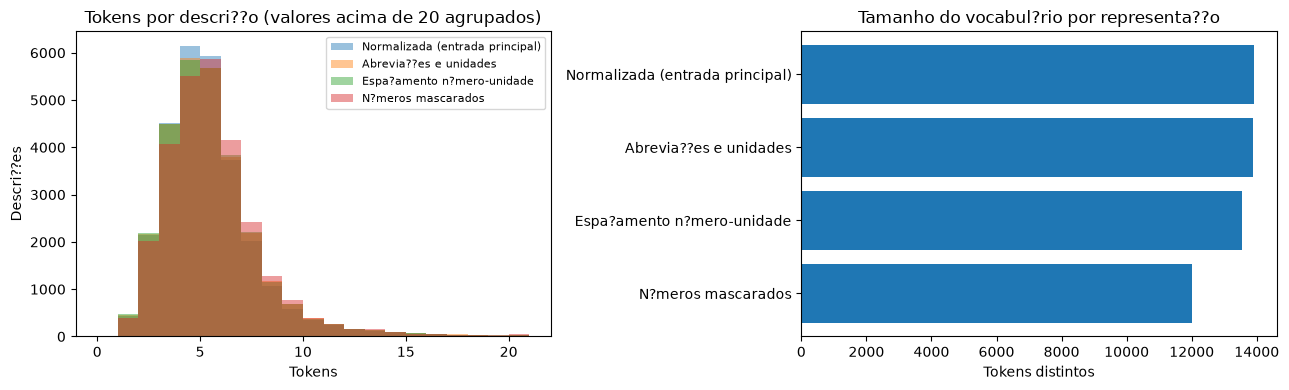

In [27]:
description_summary = pd.DataFrame(
    {
        label: summarize_description_column(df, column)
        for label, column in DESCRIPTION_COLUMNS.items()
    }
).T

display(description_summary.style.format({
    "tokens por descri??o ? mediana": "{:.1f}",
    "tokens por descri??o ? p90": "{:.1f}",
    "caracteres por descri??o ? mediana": "{:.1f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, column in DESCRIPTION_COLUMNS.items():
    token_lengths = df[column].fillna("").map(lambda value: len(tokenize_description(value)))
    axes[0].hist(token_lengths.clip(upper=20), bins=range(0, 22), alpha=0.45, label=label)
axes[0].set(title="Tokens por descri??o (valores acima de 20 agrupados)", xlabel="Tokens", ylabel="Descri??es")
axes[0].legend(fontsize=8)

summary_plot = description_summary["vocabul?rio (tokens distintos)"].sort_values()
axes[1].barh(summary_plot.index, summary_plot.values)
axes[1].set(title="Tamanho do vocabul?rio por representa??o", xlabel="Tokens distintos")
fig.tight_layout()
plt.show()

## 3. Palavras mais comuns

A tabela abaixo conta tokens repetidos dentro de uma descri??o como ocorr?ncias repetidas, assim como o vetorizador padr?o. ?Descri??es com token? conta presen?a uma ?nica vez por documento. A ordena??o principal ? pela representa??o normalizada; repita a c?lula trocando `ANALYSIS_COLUMN` para inspecionar outra variante.

,token,document_occurrences,documents_with_token,frequency_weighted_occurrences
0,de,4282,3952,18334
1,kg,2387,2183,18241
2,tipo,1220,1179,5082
3,lampada,1216,1214,2006
4,em,1040,1020,5134
5,1kg,897,895,2377
6,leite,861,860,3456
7,po,840,829,3391
8,un,724,631,2593
9,com,679,658,1997


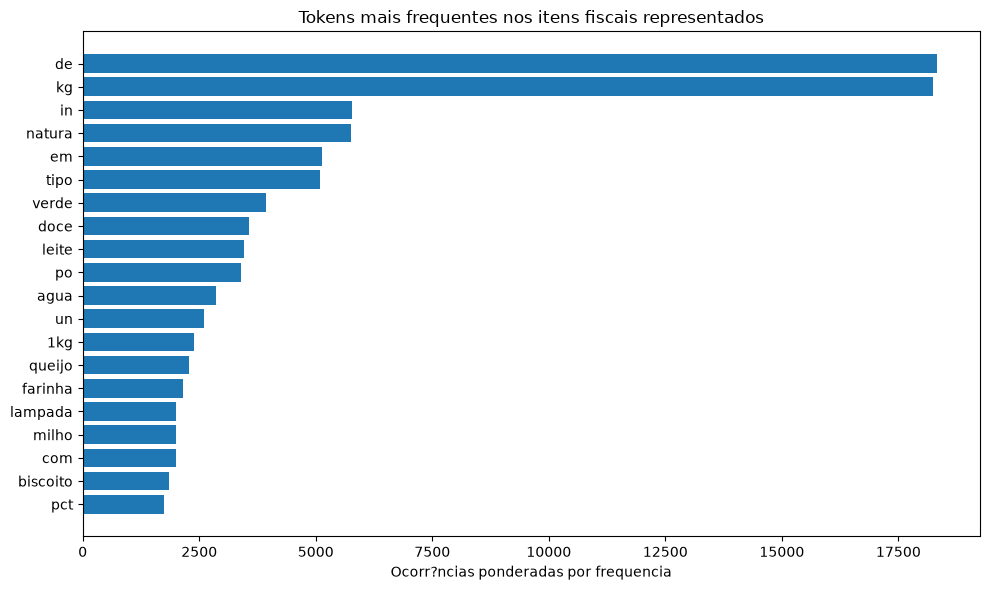

In [28]:
ANALYSIS_COLUMN = DESCRIPTION_COLUMNS["Normalizada (entrada principal)"]

common_words = word_frequency_table(df, ANALYSIS_COLUMN, TOP_N)
display(common_words)

weighted_words = common_words.nlargest(20, "frequency_weighted_occurrences").sort_values(
    "frequency_weighted_occurrences"
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(weighted_words["token"], weighted_words["frequency_weighted_occurrences"])
ax.set(title="Tokens mais frequentes nos itens fiscais representados", xlabel="Ocorr?ncias ponderadas por frequencia")
fig.tight_layout()
plt.show()

## 4. Comparar vocabul?rios e termos dominantes

Este quadro ajuda a identificar se as regras experimentais juntam variantes lexicais ou preservam tokens de quantidade. A contagem ponderada serve para interpretar o volume de compras representado, enquanto a contagem de documentos descreve a matriz TF-IDF quando cada descri??o ?nica ? uma linha.

In [29]:
variant_word_tables = {}
for label, column in DESCRIPTION_COLUMNS.items():
    variant_word_tables[label] = word_frequency_table(df, column, TOP_N)

variant_top_words = pd.concat(
    [table.assign(representation=label) for label, table in variant_word_tables.items()],
    ignore_index=True,
)[["representation", "token", "document_occurrences", "documents_with_token", "frequency_weighted_occurrences"]]

display(variant_top_words)

,representation,token,document_occurrences,documents_with_token,frequency_weighted_occurrences
0,Normalizada (entrada principal),de,4282,3952,18334
1,Normalizada (entrada principal),kg,2387,2183,18241
2,Normalizada (entrada principal),tipo,1220,1179,5082
3,Normalizada (entrada principal),lampada,1216,1214,2006
4,Normalizada (entrada principal),em,1040,1020,5134
...,...,...,...,...,...
115,N?meros mascarados,milho,404,403,2005
116,N?meros mascarados,biscoito,395,395,1842
117,N?meros mascarados,sal,392,388,1273
118,N?meros mascarados,pao,390,385,2105


## 5. Inspecionar descri??es concretas

A amostra percorre descri??es curtas, medianas e longas. Leia os exemplos junto aos termos frequentes: abrevia??es, n?meros, unidades e ru?do textual podem afetar os documentos e o vocabul?rio do TF-IDF.

In [30]:
description_samples = sample_descriptions(df, ANALYSIS_COLUMN, SAMPLE_SIZE)
display(description_samples)

# Compara??o lado a lado das representa??es para uma amostra reproduz?vel.
sample_indices = df.sample(min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).index
comparison_columns = [FREQUENCY_COLUMN, *DESCRIPTION_COLUMNS.values()]
display(df.loc[sample_indices, comparison_columns].sort_values(FREQUENCY_COLUMN, ascending=False).reset_index(drop=True))

,descricao_normalizada,frequencia,primeiro_mes,ultimo_mes
0,laranja,524,2025-01,2025-04
1,colorau po,1,2025-03,2025-03
2,vinagre branco,1,2025-03,2025-03
3,rolo la 5cm,1,2025-02,2025-02
4,queijo minas c 1kg,1,2025-01,2025-01
5,trincha atlas 395 x 3,1,2025-02,2025-02
6,gelatina sabor variados,1,2025-02,2025-02
7,maionese embalagem 500gr,1,2025-02,2025-02
8,melado de cana 250g,3,2025-02,2025-02
9,mini pao de leite,1,2025-04,2025-04


,frequencia,descricao_normalizada,descricao_abreviacoes_unidades,descricao_numero_unidade_padronizada,descricao_numeros_mascarados
0,10,milho verde em conserva predilecta kg,milho verde em conserva predilecta kg,milho verde em conserva predilecta kg,milho verde em conserva predilecta kg
1,7,alho descascado kg,alho descascado kg,alho descascado kg,alho descascado kg
2,5,copo descartavel 300ml happy,copo descartavel 300ml happy,copo descartavel 300 ml happy,copo descartavel numero ml happy
3,3,creme de leite 200gr terra viva,creme de leite 200gr terra viva,creme de leite 200gr terra viva,creme de leite 200gr terra viva
4,2,quiabo acond c,quiabo acond com,quiabo acond c,quiabo acond c
5,2,pera william natural,pera william natural,pera william natural,pera william natural
6,2,desinfetante liq lavanda grf 1l lymp,desinfetante liq lavanda grf 1l lymp,desinfetante liq lavanda grf 1 l lymp,desinfetante liq lavanda grf numero l lymp
7,2,fresubin 2kcal creme baunilha 125g,fresubin 2kcal creme baunilha 125g,fresubin 2kcal creme baunilha 125 g,fresubin 2kcal creme baunilha numero g
8,2,lustra movel 200ml,lustra movel 200ml,lustra movel 200 ml,lustra movel numero ml
9,1,milho pipoca mika 400g nacional,milho pipoca mika 400g nacional,milho pipoca mika 400 g nacional,milho pipoca mika numero g nacional


## 6. Pontos para decidir antes do TF-IDF

Use os resultados para registrar suas decis?es:

- **Representa??o:** qual coluna ser? entrada: texto normalizado, unidades/abrevia??es padronizadas, espa?amento can?nico ou n?meros mascarados?
- **Tokens curtos e ru?do:** h? termos frequentes que deveriam ser mantidos, tratados como stopwords ou normalizados? Revise exemplos antes de excluir conte?do.
- **N?meros e unidades:** os tamanhos/quantidades ajudam a distinguir produtos ou criam fragmenta??o excessiva?
- **Documentos ?nicos versus frequ?ncia:** o fluxo atual representa cada descri??o ?nica uma vez; avalie separadamente se o objetivo pede peso por frequ?ncia.
- **Par?metros do vetorizador:** `ngram_range`, `min_df`, `max_df` e `max_features` devem ser comparados no notebook 45, com base no vocabul?rio e nos exemplos observados.

Este notebook ? explorat?rio: as contagens n?o determinam, sozinhas, quais termos devem ser removidos.